In [7]:
import os, os.path

from sys import stdout

import matplotlib.pyplot as plt
import mdtraj
import nglview
import numpy as np
import pandas as pd

from openmm import *
from openmm.app import *
from openmm.unit import *
from openmm.app import ForceField
from openmm.app import PDBFile

#from openff.toolkit.topology import Molecule
from openmmforcefields.generators import GAFFTemplateGenerator

import mdtraj as md

def even_more_optimised_dist(initial_coords, coord_matrix, box_size):
    delta_x = np.absolute(initial_coords[:,0]-coord_matrix[:,:,0])
    delta_x = np.minimum(delta_x, box_size-delta_x)

    delta_y = np.absolute(initial_coords[:,1]-coord_matrix[:,:,1])
    delta_y = np.minimum(delta_y, box_size-delta_y)

    delta_z = np.absolute(initial_coords[:,2]-coord_matrix[:,:,2])
    delta_z = np.minimum(delta_z, box_size-delta_z)

    return np.sqrt(delta_x**2+delta_y**2+delta_z**2)

def optimised_dist(coord_1, coords, box_size):
    delta_x = abs(coord_1[0]-coords[:,0])
    delta_x = np.minimum(delta_x, box_size-delta_x)

    delta_y = abs(coord_1[1]-coords[:,1])
    delta_y = np.minimum(delta_y, box_size-delta_y)

    delta_z = abs(coord_1[2]-coords[:,2])
    delta_z = np.minimum(delta_z, box_size-delta_z)

    return np.sqrt(delta_x**2+delta_y**2+delta_z**2)

def p_dist(coord_1, coord_2, box_size):
    x = min(box_size-abs(coord_1[0]-coord_2[0]), abs(coord_1[0]-coord_2[0]))
    y = min(box_size-abs(coord_1[1]-coord_2[1]), abs(coord_1[1]-coord_2[1]))
    z = min(box_size-abs(coord_1[2]-coord_2[2]), abs(coord_1[2]-coord_2[2]))

    return np.sqrt((x**2+y**2+z**2))

/opt/miniconda3/envs/deeporigin/lib/python3.13/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [14]:
SIZE = 5
STEP_SIZE = 0.002
STEPS = 50000
INTERVAL = 100

inpcrd = AmberInpcrdFile('caffeine-large.rst7')
prmtop = AmberPrmtopFile('caffeine-large.prmtop', periodicBoxVectors=(Vec3(x=SIZE, y=0.0, z=0.0), Vec3(x=0.0, y=SIZE, z=0.0), Vec3(x=0.0, y=0.0, z=SIZE)))
system = prmtop.createSystem(nonbondedMethod=PME, nonbondedCutoff=1*nanometer,
        constraints=HBonds)

In [4]:
integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, STEP_SIZE*picosecond)

simulation = Simulation(prmtop.topology, system, integrator)
simulation.context.setPositions(inpcrd.positions)
print('Minimizing...')
simulation.minimizeEnergy()

print('Simulating...')
simulation.reporters.append(DCDReporter('trajectory_displacement.dcd', INTERVAL))
simulation.reporters.append(StateDataReporter(stdout, 10000, step=True,
        potentialEnergy=True, temperature=True))
simulation.step(STEPS)

Minimizing...
Simulating...
#"Step","Potential Energy (kJ/mole)","Temperature (K)"
10000,-131668.6984448461,298.14076631450365
20000,-131990.0382885961,299.6687841866962
30000,-131698.5578198461,302.4401278509056
40000,-131874.7804760961,299.58261235521195
50000,-131463.9289135961,302.6393924574849


In [5]:
t = md.load('trajectory_displacement.dcd', top='caffeine-large.pdb')

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


In [6]:
[index_caffine] = [i for i, atom in enumerate(t[0].topology.atoms) if atom.residue.name == 'LIG' and atom.name == 'C']
print(index_caffine)

6


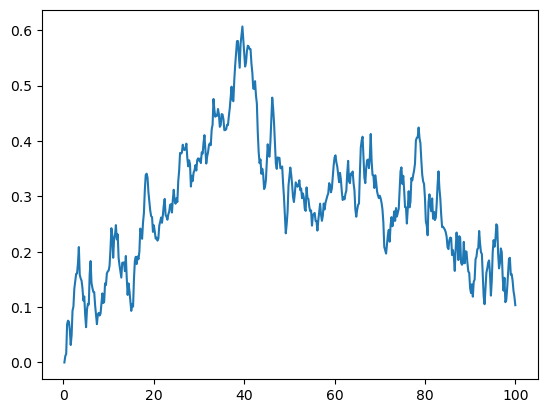

In [108]:
first_coord = t.xyz[0][6]
times = [STEP_SIZE*INTERVAL*(i+1) for i in range(STEPS//INTERVAL)]

caffeine_coords = t.xyz[:,6,:]

dists = optimised_dist(first_coord, caffeine_coords, 5)

fig, ax = plt.subplots()
ax.plot(times, dists)

In [ ]:
fig, ax1 = plt.subplots()
fig, ax2 = plt.subplots()
av_dists = []

#for i, colour in zip(range(300), ['blue', 'green', 'red', 'magenta', 'black']): 
for i in range(300): 
    integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, stepSize*picosecond)

    simulation = Simulation(prmtop.topology, system, integrator)
    simulation.context.setPositions(inpcrd.positions)
    print('Minimizing...')
    simulation.minimizeEnergy()

    print('Simulating...')
    simulation.reporters.append(DCDReporter(f'temp_output{i+1}.dcd', INTERVAL))
    #simulation.reporters.append(StateDataReporter(stdout, 10000, step=True,
    #        potentialEnergy=True, temperature=True))
    simulation.step(STEPS)
    print(f'Simulation {i+1} done.')

    t = md.load(f'temp_output{i+1}.dcd', top='caffeine-large.pdb')

    first_coord = t.xyz[0][6]
    times = [STEP_SIZE*INTERVAL*(i+1) for i in range(STEPS//INTERVAL)]

    caffeine_coords = t.xyz[:,6,:]

    dists = optimised_dist(first_coord, caffeine_coords, SIZE)
    av_dists.append(dists)

    #ax1.plot(times, dists, color=colour)
    ax1.plot(times, dists)
    ax1.set_title('Displacement vs Time (300 Simulations)')
    ax1.set_xlabel('Time Elapsed (picoseconds)')
    ax1.set_ylabel('Displacement (nanometers)')

av_dists = np.mean(av_dists, axis=0)

ax2.plot(times, av_dists)
ax2.set_title('Av. Displacement vs Time')
ax2.set_xlabel('Time Elapsed (picoseconds)')
ax2.set_ylabel('Displacement (nanometers)')

In [ ]:
multi_sim_trajectories = []
for sim in [name for name in os.listdir('Other Sims') if name != ".DS_Store"]:
    print(f'Loading {sim}...')
    t = md.load(f'Other Sims/{sim}', top='caffeine-large.pdb')
    multi_sim_trajectories.append(t)

In [ ]:
multi_sim_coords = []
for t in multi_sim_trajectories:
    multi_sim_coords.append(t.xyz)

multi_sim_coords = np.array(multi_sim_coords, dtype='object')

#print(type(multi_sim_coords))
#print(multi_sim_coords)
#print([shape for shape in shapes if shape != (500, 9451, 3)])
#print(len(multi_sim_coords))
#print(np.shape(multi_sim_coords))

In [110]:
#print(multi_sim_coords)

#print(multi_sim_coords[:,0,6,:])
#print(multi_sim_coords[:,:,6,:])
#print(np.rot90(np.fliplr(multi_sim_coords[:,:,6,:]), 1, (0,1)))

#print(np.shape(multi_sim_coords[:,0,6,:]))
#print(np.shape(multi_sim_coords[:,:,6,:]))
#print(np.shape(np.rot90(np.fliplr(multi_sim_coords[:,:,6,:]), 1, (0,1))))

#print(multi_sim_coords[:,0,6,0])
#print(multi_sim_coords[:,:,6,0])
#print(multi_sim_coords[:,0,6,0]-multi_sim_coords[:,:,6,0])

caffeine_dists = even_more_optimised_dist(multi_sim_coords[:,0,6,:], np.rot90(np.fliplr(multi_sim_coords[:,:,6,:]), 1, (0,1)), SIZE)

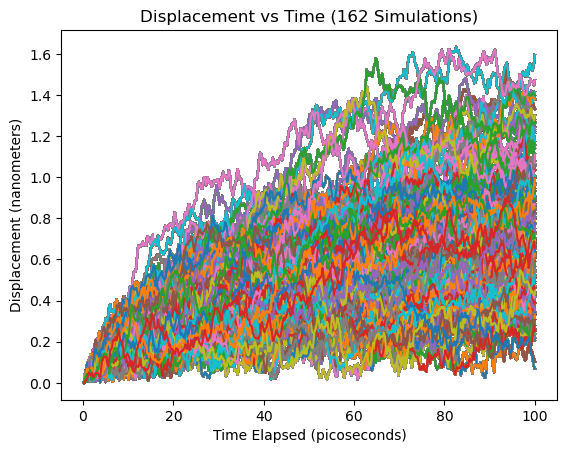

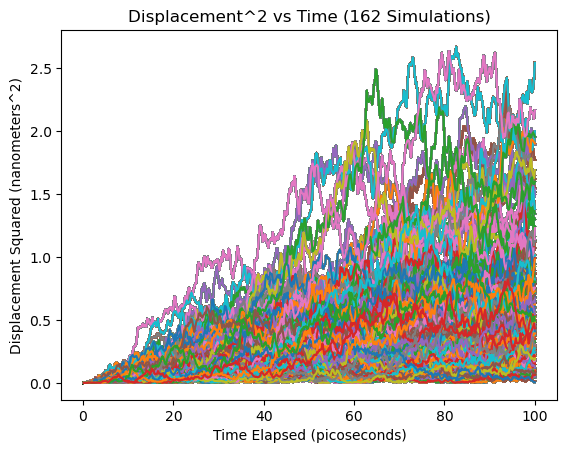

In [ ]:
#print(np.rot90(np.fliplr(dists), 1, (0,1)))
#print(len(np.rot90(np.fliplr(dists), 1, (0,1))))

times = [STEP_SIZE*INTERVAL*(i+1) for i in range(STEPS//INTERVAL)]
fig, ax1 = plt.subplots()
fig, ax2 = plt.subplots()

for sim_dists in np.rot90(np.fliplr(caffeine_dists), 1, (0,1)):

    ax1.plot(times, caffeine_dists)
    ax1.set_title(f'Displacement vs Time ({len(np.rot90(np.fliplr(dists), 1, (0,1)))} Simulations)')
    ax1.set_xlabel('Time Elapsed (picoseconds)')
    ax1.set_ylabel('Displacement (nanometers)')

    ax2.plot(times, caffeine_dists**2)
    ax2.set_title(f'Displacement^2 vs Time ({len(np.rot90(np.fliplr(dists), 1, (0,1)))} Simulations)')
    ax2.set_xlabel('Time Elapsed (picoseconds)')
    ax2.set_ylabel('Displacement Squared (nanometers^2)')


Text(0, 0.5, 'Displacement Squared (nanometers^2)')

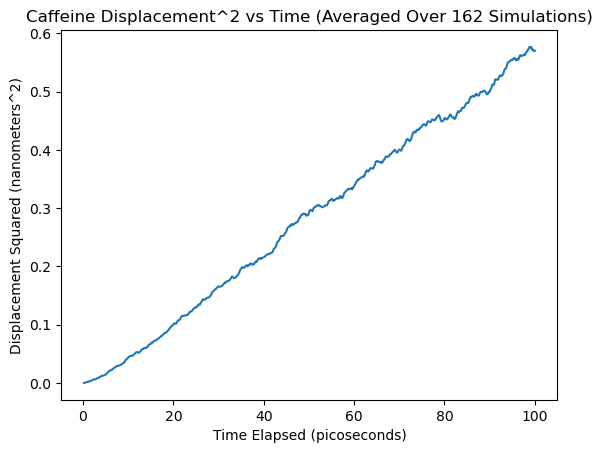

In [349]:
multi_sim_av_caffeine_dists = np.average(caffeine_dists, axis=1)**2

fig, ax = plt.subplots()
ax.plot(times, multi_sim_av_caffeine_dists)
ax.set_title(f'Caffeine Displacement^2 vs Time (Averaged Over {len(np.rot90(np.fliplr(caffeine_dists), 1, (0,1)))} Simulations)')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Displacement Squared (nanometers^2)')

In [353]:
caffeine_gradients = [0]
for i in range(len(times)):
    if i < len(times)-1:
        rise = multi_sim_av_caffeine_dists[i+1] - multi_sim_av_caffeine_dists[i]
        run = times[i+1] - times[i]
        caffeine_gradients.append(float(rise/run))
print(caffeine_gradients)

[0, 0.0014928715536370873, 0.0028559069614857435, 0.0027849564794451, 0.0023251224774867296, 0.0017733534332364798, 0.0031576515175402164, 0.0015321443788707256, 0.003119909670203924, 0.004353367257863283, 0.003917906433343887, 0.0016234815120697021, 0.002011386677622795, 0.001206682063639164, 0.0044372910633683205, 0.004922081716358662, 0.0041295308619737625, 0.001214565709233284, 0.005536885000765324, 0.005417373031377792, 0.002551944926381111, 0.00255584716796875, 0.0013484247028827667, 0.004592202603816986, 0.0026129325851798058, 0.006417934782803059, 0.008648545481264591, 0.009315982460975647, 0.00638764351606369, 0.0035874731838703156, 0.004999497905373573, 0.0012583937495946884, 0.00789315439760685, 0.007322933524847031, 0.00391191802918911, 0.004735318943858147, 0.007888339459896088, 0.001336047425866127, 0.0011356547474861145, 0.004360741004347801, 0.002471599727869034, 0.0036297086626291275, 0.0053433701395988464, 0.0039130449295043945, 0.005335956811904907, 0.010128095746040

2


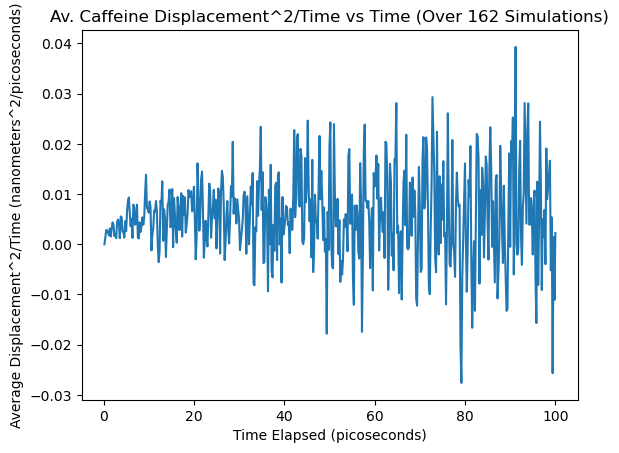

In [356]:
fig, ax = plt.subplots()

ax.plot(times, caffeine_gradients)
ax.set_title(f'Av. Caffeine Displacement^2/Time vs Time (Over {len(multi_sim_coords)} Simulations)')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Displacement^2/Time (nanometers^2/picoseconds)')
for i, grad in enumerate(caffeine_gradients):
    if grad<caffeine_gradients[i-1] and i != 0:
        print(i-1)
        break

In [355]:
print(np.mean(caffeine_gradients))

0.005699541568057611


In [328]:
t = md.load('Other Sims/temp_output1.dcd', top='caffeine-large.pdb')

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


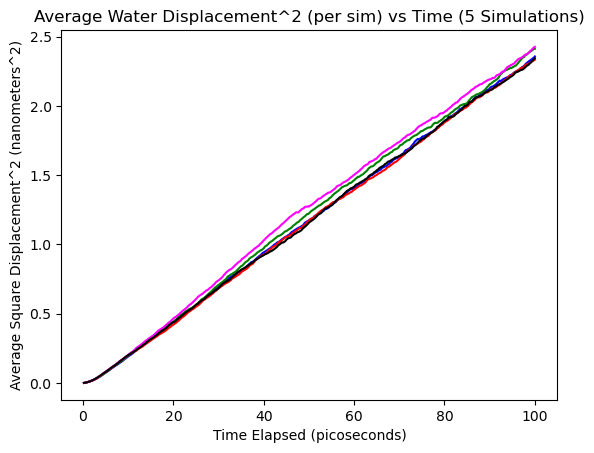

In [329]:
fig, ax = plt.subplots()
times = [STEP_SIZE*INTERVAL*(i+1) for i in range(STEPS//INTERVAL)]

for i, colour in zip(range(5), ['blue', 'green', 'red', 'magenta', 'black']): 
    t = md.load(f'Other Sims/temp_output{i+1}.dcd', top='caffeine-large.pdb')

    oxygen_indexes = [atom.index for atom in t[0].topology.atoms if atom.element.symbol == 'O']
    oxygen_coords = t.xyz[:,oxygen_indexes,:]
    #print(np.shape(oxygen_coords))
    #print(oxygen_coords)
    dists = even_more_optimised_dist(oxygen_coords[0], oxygen_coords, SIZE)
    #print(np.shape(oxygen_coords[0][:, 0]), np.shape(oxygen_coords[:,:,0]))
    #print(np.shape(oxygen_coords[0]), np.shape(oxygen_coords))
    #print(oxygen_coords[0])
    #print(oxygen_coords)
    av_oxygen_dists_squared = np.mean(dists,axis=1)**2

    ax.plot(times, av_oxygen_dists_squared, color=colour)
    ax.set_title('Average Water Displacement^2 (per sim) vs Time (5 Simulations)')
    ax.set_xlabel('Time Elapsed (picoseconds)')
    ax.set_ylabel('Average Square Displacement^2 (nanometers^2)')

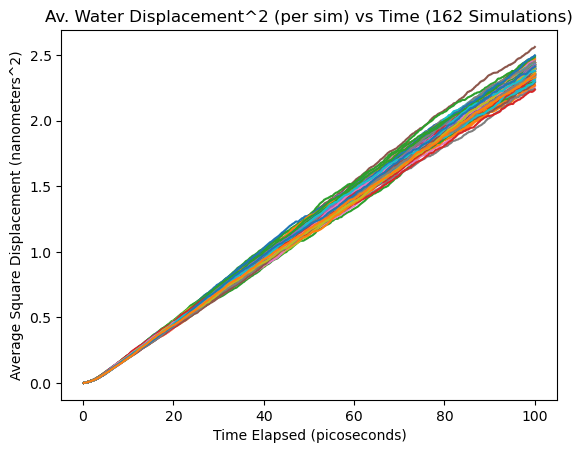

In [358]:
fig, ax = plt.subplots()
times = [STEP_SIZE*INTERVAL*(i+1) for i in range(STEPS//INTERVAL)]
oxygen_indexes = [atom.index for atom in t[0].topology.atoms if atom.element.symbol == 'O']
total_average_oxygen_dists_squared = []

for i in range(len(multi_sim_coords)):
    oxygen_coords = np.rot90(np.fliplr(multi_sim_coords[i,:,oxygen_indexes,:]), 1, (0,1))
    #print(oxygen_coords[:,:,0].min(), oxygen_coords[:,:,0].max(), oxygen_coords[:,:,1].min(), oxygen_coords[:,:,1].max(), oxygen_coords[:,:,2].min(), oxygen_coords[:,:,2].max())
    #print(np.shape(oxygen_coords))
    dists = even_more_optimised_dist(oxygen_coords[0], oxygen_coords, SIZE)
    av_oxygen_dists_squared = np.mean(dists,axis=1)**2
    total_average_oxygen_dists_squared.append(av_oxygen_dists_squared)

    ax.plot(times, av_oxygen_dists_squared)
    ax.set_title(f'Av. Water Displacement^2 (per sim) vs Time ({len(multi_sim_coords)} Simulations)')
    ax.set_xlabel('Time Elapsed (picoseconds)')
    ax.set_ylabel('Average Square Displacement (nanometers^2)')

total_average_oxygen_dists_squared = np.average(total_average_oxygen_dists_squared, axis=0)

Text(0, 0.5, 'Average Square Displacement (nanometers^2)')

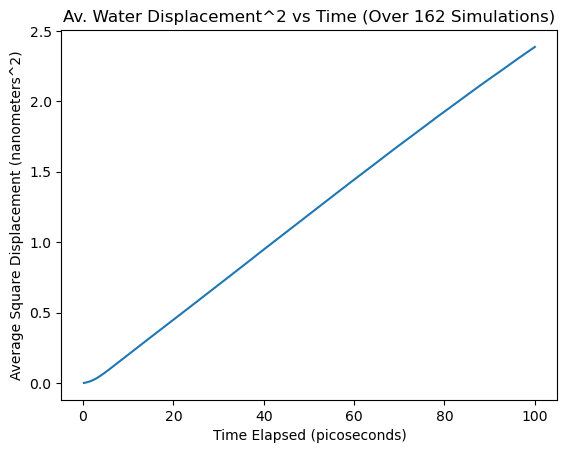

In [359]:
fig, ax = plt.subplots()

ax.plot(times, total_average_oxygen_dists_squared)
ax.set_title(f'Av. Water Displacement^2 vs Time (Over {len(multi_sim_coords)} Simulations)')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Square Displacement (nanometers^2)')

In [360]:
gradients = [0]
for i in range(len(times)):
    if i < len(times)-1:
        rise = total_average_oxygen_dists_squared[i+1] - total_average_oxygen_dists_squared[i]
        run = times[i+1] - times[i]
        gradients.append(float(rise/run))
print(gradients)

[0, 0.0049816337414085865, 0.006690141744911671, 0.007647380698472261, 0.008860322646796703, 0.009910939261317253, 0.010709860362112522, 0.011510155163705349, 0.012465417385101318, 0.013370993547141552, 0.014133704826235771, 0.015124501660466194, 0.016116956248879433, 0.01703862100839615, 0.017956793308258057, 0.018992405384778976, 0.01973893493413925, 0.020898375660181046, 0.02141423523426056, 0.0217340886592865, 0.021854545921087265, 0.02252204343676567, 0.022972002625465393, 0.023392774164676666, 0.023591183125972748, 0.024052634835243225, 0.024277083575725555, 0.024506784975528717, 0.02465754747390747, 0.024998188018798828, 0.02430405467748642, 0.024594739079475403, 0.02492312341928482, 0.02514168620109558, 0.02479761838912964, 0.024924427270889282, 0.024575963616371155, 0.0246506929397583, 0.02495802938938141, 0.024931952357292175, 0.024664849042892456, 0.025060325860977173, 0.025025755167007446, 0.024700239300727844, 0.024664252996444702, 0.024646073579788208, 0.02483978867530822

29


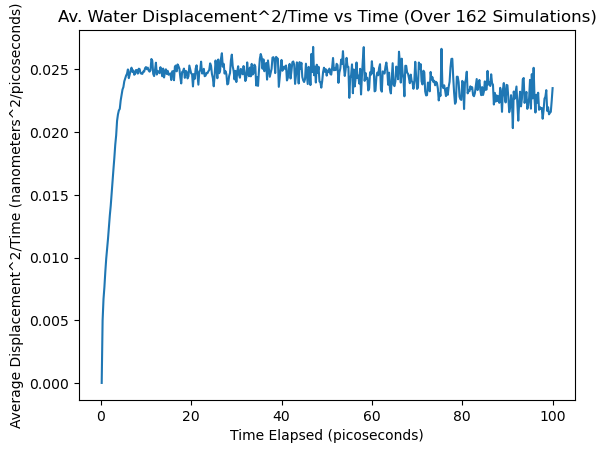

In [363]:
fig, ax = plt.subplots()

ax.plot(times, gradients)
ax.set_title(f'Av. Water Displacement^2/Time vs Time (Over {len(multi_sim_coords)} Simulations)')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Displacement^2/Time (nanometers^2/picoseconds)')
for i, grad in enumerate(gradients):
    if grad<gradients[i-1] and i != 0:
        print(i-1)
        break

In [364]:
print(np.mean(gradients[29:]))

0.024307985372857176


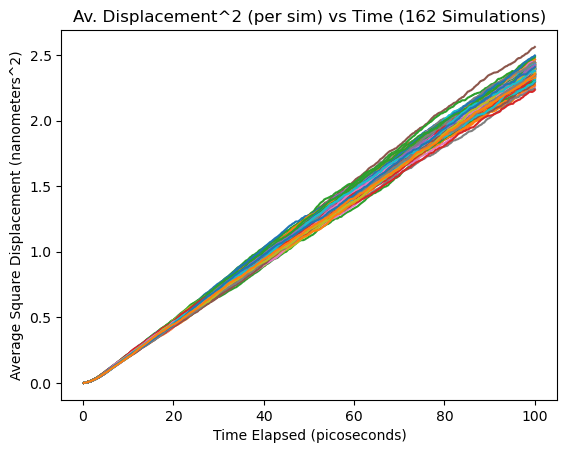

In [261]:
fig, ax = plt.subplots()
times = [STEP_SIZE*INTERVAL*(i+1) for i in range(STEPS//INTERVAL)]
total_average_dists_squared = []

for i in range(len(multi_sim_coords)):
    coords = multi_sim_coords[i,:,:,:]
    #print(coords)
    dists = even_more_optimised_dist(coords[0], coords, SIZE)
    #print(np.shape(coords))
    dists = even_more_optimised_dist(coords[0], coords, SIZE)
    #print(dists)
    #print(np.shape(dists))
    av_dists_squared = np.mean(dists,axis=1)**2
    total_average_dists_squared.append(av_dists_squared)

    ax.plot(times, av_dists_squared)
    ax.set_title(f'Av. Displacement^2 (per sim) vs Time ({len(multi_sim_coords)} Simulations)')
    ax.set_xlabel('Time Elapsed (picoseconds)')
    ax.set_ylabel('Average Square Displacement (nanometers^2)')

total_average_dists_squared = np.average(total_average_dists_squared, axis=0)

Text(0, 0.5, 'Average Square Displacement (nanometers^2)')

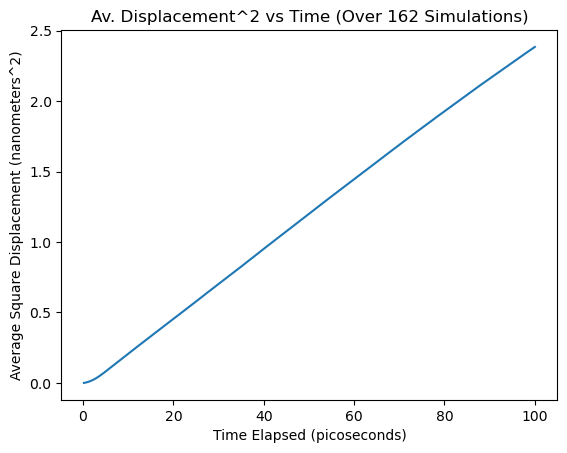

In [262]:
fig, ax = plt.subplots()
ax.plot(times, total_average_dists_squared)
ax.set_title(f'Av. Displacement^2 vs Time (Over {len(multi_sim_coords)} Simulations)')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Square Displacement (nanometers^2)')

In [ ]:
gradients = [0]
for i in range(len(times)):
    if i < len(times)-1:
        rise = total_average_dists_squared[i+1] - total_average_dists_squared[i]
        run = times[i+1] - times[i]
        gradients.append(float(rise/run))
print(gradients)

[0, 0.005390042904764414, 0.006897951941937208, 0.007995123974978924, 0.00928404275327921, 0.010438553988933563, 0.011333185248076916, 0.012239394709467888, 0.01332004088908434, 0.014305394142866135, 0.015168460085988045, 0.016206353902816772, 0.017301607877016068, 0.01827002502977848, 0.019255466759204865, 0.020283292979002, 0.021085869520902634, 0.022223275154829025, 0.022649690508842468, 0.022967178374528885, 0.02300148829817772, 0.02376597374677658, 0.023975186049938202, 0.024438127875328064, 0.02448044717311859, 0.024909190833568573, 0.025121457874774933, 0.025363191962242126, 0.025387071073055267, 0.02571001648902893, 0.024763979017734528, 0.025243274867534637, 0.025404877960681915, 0.025633834302425385, 0.02527758479118347, 0.025159716606140137, 0.02486974000930786, 0.024911165237426758, 0.025315061211586, 0.02505466341972351, 0.02482786774635315, 0.02539008855819702, 0.025125369429588318, 0.02477683126926422, 0.02486191689968109, 0.02473399043083191, 0.024789944291114807, 0.025

29


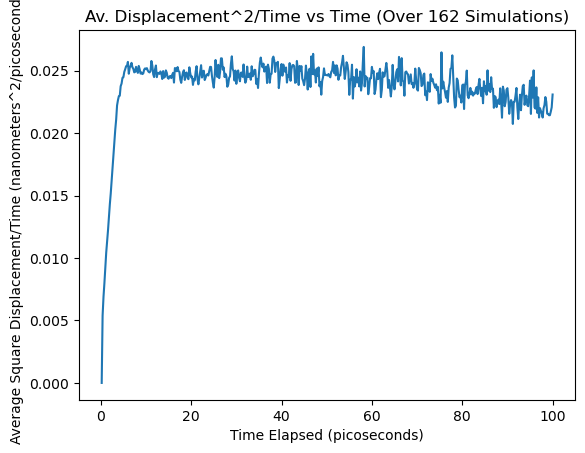

In [287]:
fig, ax = plt.subplots()

#dx = times[5] - times[0]
#gradients = np.gradient(total_average_dists_squared, dx)

ax.plot(times, gradients)
ax.set_title(f'Av. Displacement^2/Time vs Time (Over {len(multi_sim_coords)} Simulations)')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Square Displacement/Time (nanometers^2/picoseconds)')
for i, grad in enumerate(gradients):
    if grad<gradients[i-1] and i != 0:
        print(i-1)
        break

In [290]:
print(np.mean(gradients[29:]))

0.02423543759845118


In [296]:
forcefield = ForceField('tip3p.xml')

topology = Topology()
positions = []

modeller = Modeller(topology, positions)

modeller.addSolvent(forcefield,
                    boxSize=Vec3(SIZE, SIZE, SIZE)*nanometer,
                    model='tip3p')

with open('top_displacement_water.pdb', 'w') as f:
    PDBFile.writeFile(modeller.topology, modeller.positions, f)

In [298]:
system = forcefield.createSystem(modeller.topology,
                                 nonbondedMethod=PME,
                                 nonbondedCutoff=1.0*nanometer,
                                 constraints=HBonds)

integrator = LangevinIntegrator(
    300, #Temp (Kelvin)
    1, #Friction Coefficient (1/picoseconds)
    0.002 #Step Increment (picoseconds)
)

simulation = Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

print('Minimizing...')
simulation.minimizeEnergy()

print('Simulating...')
simulation.reporters.append(XTCReporter('trajectory_displacement_water.xtc', 100))
simulation.reporters.append(StateDataReporter(stdout, 10000, step=True, potentialEnergy=True, temperature=True))

simulation.step(50000)

Minimizing...
Simulating...
#"Step","Potential Energy (kJ/mole)","Temperature (K)"
10000,-162957.07751661993,301.5192946141623
20000,-163350.46032911993,296.29450103030507
30000,-162759.30017286993,299.37220661818947
40000,-162776.22204786993,299.8870714143737
50000,-162828.35095411993,301.2173384982633


In [303]:
t = md.load('trajectory_displacement_water.xtc', top='top_displacement_water.pdb')
water_coords = t.xyz
np.shape(water_coords)

(500, 12255, 3)

Text(0, 0.5, 'Average Square Displacement (nanometers^2)')

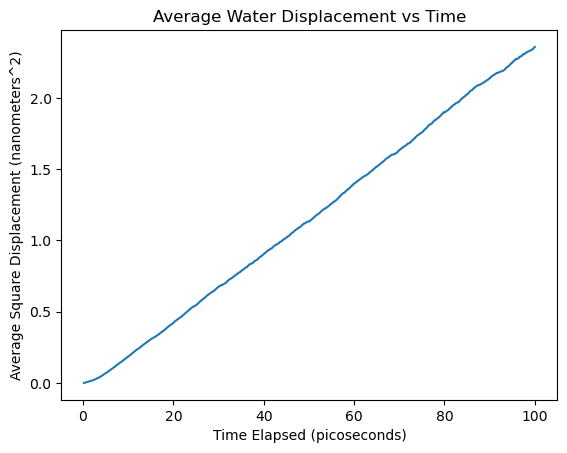

In [315]:
water_dists_squared = np.average(even_more_optimised_dist(water_coords[0], water_coords, SIZE), axis=1)**2

fig, ax = plt.subplots()

ax.plot(times, water_dists_squared)
ax.set_title('Average Water Displacement vs Time')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Square Displacement (nanometers^2)')

In [321]:
gradients = [0]
for i in range(len(times)):
    if i < len(times)-1:
        rise = water_dists_squared[i+1] - water_dists_squared[i]
        run = times[i+1] - times[i]
        gradients.append(float(rise/run))
print(gradients)

[0, 0.007200043182820082, 0.010042554698884487, 0.009283948689699173, 0.00820008572191, 0.008984340354800224, 0.009034201502799988, 0.009799916297197342, 0.011671660467982292, 0.00965275801718235, 0.010846192017197609, 0.011946503072977066, 0.014108298346400261, 0.01469348557293415, 0.012745195999741554, 0.01590833067893982, 0.016039349138736725, 0.016587302088737488, 0.018508508801460266, 0.01878848299384117, 0.01991787925362587, 0.022394433617591858, 0.023669954389333725, 0.021483395248651505, 0.016848519444465637, 0.018203891813755035, 0.023266412317752838, 0.023393966257572174, 0.02371218055486679, 0.018893443048000336, 0.023710690438747406, 0.025421716272830963, 0.023924410343170166, 0.022013336420059204, 0.021733790636062622, 0.026809535920619965, 0.03067508339881897, 0.024257786571979523, 0.019542649388313293, 0.019070729613304138, 0.027488693594932556, 0.02205178141593933, 0.019959881901741028, 0.027824193239212036, 0.02639584243297577, 0.024708732962608337, 0.02421788871288299

2


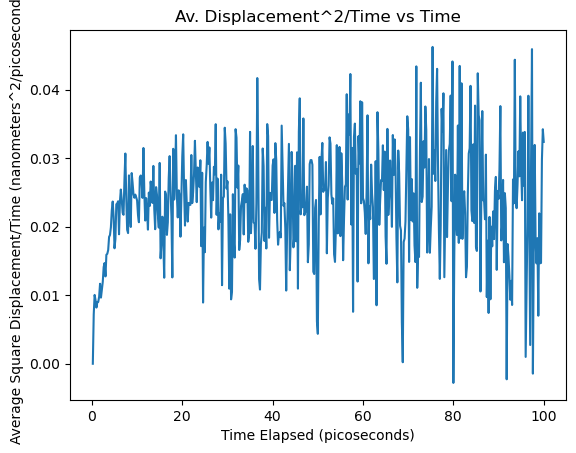

In [322]:
fig, ax = plt.subplots()

#dx = times[5] - times[0]
#gradients = np.gradient(total_average_dists_squared, dx)

ax.plot(times, gradients)
ax.set_title(f'Av. Displacement^2/Time vs Time')
ax.set_xlabel('Time Elapsed (picoseconds)')
ax.set_ylabel('Average Square Displacement/Time (nanometers^2/picoseconds)')
for i, grad in enumerate(gradients):
    if grad<gradients[i-1] and i != 0:
        print(i-1)
        break